# Hybrid fixed-point and phase arithmetic

$\renewcommand{\ket}[1]{\left|#1\right\rangle}\renewcommand{\bra}[1]{\left\langle #1\right|}\renewcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}\renewcommand{\ketbra}[2]{\left|#1\right\rangle\!\left\langle #2\right|}$

This notebook implements the hybrid Boltzmann coin described in Appendix F of the paper. The construction combines reversible fixed-point arithmetic with the [phase-arithmetic approach](https://arxiv.org/abs/2210.14892). It computes the nonsmooth positive-part operation explicitly and uses phase arithmetic only for the smooth square-root exponential. This reduces the non-Clifford depth at the cost of a larger logical-qubit count.


The hybrid coin separates the nonsmooth Metropolis clipping from the smooth exponential. Rather than approximating the complete kinked function directly with GQSP, the circuit proceeds as follows.

1. The energy-difference block computes

   $$
   \Delta H
   =
   H(y)-H(x)
   $$

   in a signed fixed-point register.

2. The positive-part selector computes

   $$
   (\Delta H)_+
   =
   \max\{0,\Delta H\}.
   $$

3. In the active-tail regime, the cutoff-tail block rescales values below the cutoff $2^{-j_{\mathrm{cut}}}$ and maps values in the discarded tail to the saturated signal value $1$.

4. One-body qubitization and GQSP apply an approximation to

   $$
   \exp\left[-\frac{\beta(\Delta H)_+}{2}\right].
   $$

5. The cutoff-tail block, positive-part selector, and energy-difference block are uncomputed.

The implementation stores the energy difference in units of the coefficient normalization $\Lambda$. Some functions retain the internal parameter name `alpha`; in this notebook, that parameter corresponds to $\Lambda$ in the paper.


## Resources

Let

$$
M
=
n+\binom{n}{2},
\qquad
w=b+1,
\qquad
s_{\mathrm{SK}}
=
\left\lceil
\log_{3/2}(2M)
\right\rceil,
\qquad
\ell_x
=
\left\lceil
\log_2x
\right\rceil.
$$

Here $b$ is the number of fractional bits and $w$ is the signed fixed-point word size. The implemented cutoff power is

$$
j_{\mathrm{cut}}
=
\max\left\{
0,
\min\left[
w-1,
\left\lfloor
\log_2\left(
\frac{\beta\Lambda}
{2\log(1/\varepsilon_{\mathrm{tail}})}
\right)
\right\rfloor
\right]
\right\}.
$$

The cutoff-tail resource estimate assumes the active-tail regime $3\leq j_{\mathrm{cut}}\leq w-1$.

### Fixed-point arithmetic

The following table reproduces Table VI of the paper.

| Component | Logical qubits | Non-Clifford depth |
|---|---:|---:|
| Conditional terms loader | $Mw+2M-n$ | $0$ |
| Three-to-two compressor | $5$ | $9$ |
| Wallace-tree adder | $6Mw-2w-2M+1$ | $18s_{\mathrm{SK}}+18w$ |
| Energy-difference block | $2n+6Mw-2w-2M+1$ | $18s_{\mathrm{SK}}+18w$ |
| Positive-part selector | $3w$ | $3$ |
| Cutoff-tail block | $2w+3$ | $14\ell_{j_{\mathrm{cut}}}+3w-3j_{\mathrm{cut}}-13$ |

### Phase arithmetic

The square-root exponential is implemented using the signal Hamiltonian

$$
H_{\mathrm{sig}}
=
\frac{1}{2}Z_{w-1}
-
\sum_{j=0}^{w-2}
2^{j-w}Z_j,
$$

which satisfies

$$
H_{\mathrm{sig}}\ket{r}
=
(\eta-r)\ket{r},
\qquad
\eta
=
1+3\cdot2^{-w}.
$$

The following table reproduces Table VII of the paper.

| Component | Logical qubits | Non-Clifford depth |
|---|---:|---:|
| One-body $\mathrm{PREPARE}$ | $w$ | $2\ell_w$ |
| One-body $\mathrm{SELECT}$ | $2w$ | $0$ |
| Controlled one-body $\mathrm{SELECT}$ | $3w$ | $3$ |
| One-body reflection | $w+2$ | $14\ell_w-10$ |
| Controlled one-body reflection | $w+3$ | $14\ell_w-10$ |
| One-body qubitized operator | $2w+2$ | $18\ell_w-10$ |
| Controlled one-body qubitized operator | $3w+2$ | $18\ell_w-7$ |
| Square-root exponential arithmetic | $3w+2$ | $d_{\mathrm{hyb}}(54\ell_w-18)+3$ |

The hybrid GQSP degree is estimated numerically as

$$
d_{\mathrm{hyb}}
\approx
\left\lceil
\log\left(\frac{1}{\varepsilon_{\mathrm{tail}}}\right)
+
\log\left(\frac{1}{\varepsilon_{\mathrm{ops}}}\right)
+
1
\right\rceil.
$$

The complete hybrid arithmetic applies the energy-difference block, positive-part selector, cutoff-tail block, and square-root exponential arithmetic, followed by the inverse cutoff-tail block, inverse positive-part selector, and inverse energy-difference block. Its non-Clifford depth is

$$
D_{\mathrm{hybrid}}
=
d_{\mathrm{hyb}}(54\ell_w-18)
+
3
+
2(18s_{\mathrm{SK}}+18w)
+
2\cdot3
+
2\left(
14\ell_{j_{\mathrm{cut}}}
+
3w
-
3j_{\mathrm{cut}}
-
13
\right),
$$

or equivalently,

$$
D_{\mathrm{hybrid}}
=
d_{\mathrm{hyb}}(54\ell_w-18)
+
36s_{\mathrm{SK}}
+
42w
-
6j_{\mathrm{cut}}
+
28\ell_{j_{\mathrm{cut}}}
-
17.
$$

The complete block uses

$$
2n+6Mw-2M+2
$$

logical qubits. With $w=O(\log(n/\varepsilon))$ and $d_{\mathrm{hyb}}=O(\log\varepsilon^{-1})$, this gives the asymptotic estimates reported in Table II:

| Component | Logical non-Clifford depth | Logical qubits |
|---|---:|---:|
| Boltzmann coin, hybrid arithmetic | $O(\log n\log\varepsilon^{-1})$ | $O(n^2\log(n/\varepsilon))$ |


## Implementation

### Conditional terms loader

For each configuration, the conditional terms loader writes all $M$ one-body and two-body contributions into signed $w$-bit rows. A one-body term loads either $+\widetilde h_i$ or $-\widetilde h_i$, while a two-body term loads either $+\widetilde J_{ij}$ or $-\widetilde J_{ij}$ according to the spin parity.

The loader uses fanout, parity computation, and classically controlled coefficient loading. These are Clifford operations, so its non-Clifford depth is zero. It uses

$$
Mw+2M-n
$$

logical qubits.

<img src="gates/hybrid-load.png" style="width: 750px">

### Three-to-two compressor

The reversible three-to-two compressor maps three input bits to a sum bit and a carry bit. It contains three sequential Toffoli gates. Since each Toffoli has non-Clifford depth three, one compressor has non-Clifford depth

$$
3\cdot3=9.
$$

It uses five logical qubits.

<img src="gates/three-two-compressor.png" style="width: 350px">

### Wallace-tree adder

The two conditional loaders produce $2M$ signed $w$-bit rows. The reversible Wallace-tree adder reduces these rows in parallel. At each reduction level, disjoint triples of rows are compressed into two rows, so the row count changes as

$$
R
\mapsto
\left\lceil
\frac{2R}{3}
\right\rceil.
$$

At most

$$
s_{\mathrm{SK}}
=
\left\lceil
\log_{3/2}(2M)
\right\rceil
$$

levels are required to reduce the initial $2M$ rows to two rows.

The forward Wallace reduction and its inverse contribute at most $18s_{\mathrm{SK}}$. The final carry computation and its inverse contribute at most $18w$. The uniform upper bound is therefore

$$
D_{\mathrm{Wallace}}
=
18s_{\mathrm{SK}}+18w.
$$

The adder uses

$$
6Mw-2w-2M+1
$$

logical qubits.

<img src="gates/wallace.png" style="width: 750px">

### Energy-difference block

The energy-difference block loads the terms of one configuration, loads the terms of the other configuration with inverted coefficients, applies the Wallace-tree adder, and uncomputes both loaders. It writes

$$
\Delta H
=
H(y)-H(x)
$$

into a signed $w$-bit register.

Because the loaders are Clifford-only, the block has non-Clifford depth

$$
18s_{\mathrm{SK}}+18w.
$$

Including the two $n$-qubit configuration registers, it uses

$$
2n+6Mw-2w-2M+1
$$

logical qubits.

The reusable `DeltaEnergy` implementation computes the energy of its first state register minus that of its second. `HybridPhaseArithmetic` therefore passes the state registers in the order $(y,x)$.

### Positive-part selector

The positive-part selector maps $\Delta H$ to $(\Delta H)_+$. It copies and fans out the sign bit using CNOT gates, then applies controlled swaps between the signed delta register and a clean zero register.

Each controlled swap contains one depth-three Toffoli and Clifford gates. Since the swaps act in parallel, the selector has non-Clifford depth three and uses $3w$ logical qubits.

### Cutoff-tail block

In the active-tail regime, the cutoff-tail block tests whether the normalized positive energy difference is above the cutoff $2^{-j_{\mathrm{cut}}}$. For $j_{\mathrm{cut}}\geq3$, the threshold test uses a two-clean-ancilla multi-controlled operation with depth

$$
14\ell_{j_{\mathrm{cut}}}-10.
$$

When the input is below the cutoff, the block writes the shifted signal using $w-j_{\mathrm{cut}}-1$ sequential Toffoli gates sharing the same tail control. This contributes

$$
3(w-j_{\mathrm{cut}}-1)
$$

to the depth. The complete cutoff-tail block therefore has depth

$$
14\ell_{j_{\mathrm{cut}}}
+
3w
-
3j_{\mathrm{cut}}
-
13
$$

and uses $2w+3$ logical qubits.

Values in the discarded tail are mapped to the saturated signal value $1$. The square-root exponential arithmetic is then applied unconditionally.

### One-body $\mathrm{PREPARE}$

The one-body preparation unitary is a balanced Givens tree over the $w$ coefficients of $H_{\mathrm{sig}}$. It has $\ell_w$ Givens layers. Since each Givens rotation has non-Clifford depth two, the preparation has depth $2\ell_w$ and uses $w$ logical qubits.

### One-body $\mathrm{SELECT}$ and controlled-$\mathrm{SELECT}$

The one-body selection unitary applies the selected signed Pauli $Z_j$ to the signal register. It is Clifford-only, has non-Clifford depth zero, and acts on $2w$ logical qubits.

The controlled selection unitary fans out the external GQSP control and applies parallel controlled-controlled-$Z$ gates. Each controlled-controlled-$Z$ is implemented by conjugating a depth-three Toffoli with Hadamard gates. The controlled selection therefore has non-Clifford depth three and uses $3w$ logical qubits.

### One-body reflections

The reflection about the zero state of the one-body selection register uses the same two-clean-ancilla multi-controlled construction as the cutoff test. The uncontrolled and controlled reflections both have depth

$$
14\ell_w-10
$$

and use $w+2$ and $w+3$ logical qubits, respectively.

### One-body qubitized operators

The one-body qubitized operator consists of $\mathrm{PREPARE}$, $\mathrm{SELECT}$, $\mathrm{PREPARE}^\dagger$, and the zero reflection. Its non-Clifford depth is

$$
2\ell_w+0+2\ell_w+(14\ell_w-10)
=
18\ell_w-10.
$$

It uses $2w+2$ logical qubits.

The controlled version replaces $\mathrm{SELECT}$ and the reflection with their controlled variants. Its depth is

$$
2\ell_w+3+2\ell_w+(14\ell_w-10)
=
18\ell_w-7,
$$

and it uses $3w+2$ logical qubits.

### Square-root exponential arithmetic

Let $r$ denote the value encoded in the signal register after the optional cutoff rescaling. Because

$$
r
=
\eta-H_{\mathrm{sig}}
$$

on valid signal states, a polynomial transformation of $H_{\mathrm{sig}}$ can approximate

$$
r
\mapsto
\exp\left(
-\frac{\beta\Lambda_{\mathrm{eff}}r}{2}
\right).
$$

In the active-tail regime,

$$
\Lambda_{\mathrm{eff}}
=
\Lambda2^{-j_{\mathrm{cut}}},
$$

because the cutoff block rescales the input by $2^{j_{\mathrm{cut}}}$ before the exponential approximation.

The implementation constructs Laurent coefficients indexed by $k=-d_{\mathrm{hyb}},\ldots,d_{\mathrm{hyb}}$. The resulting GQSP sequence uses

* $2d_{\mathrm{hyb}}$ controlled one-body qubitized calls;
* $d_{\mathrm{hyb}}$ inverse uncontrolled one-body qubitized calls;
* $2d_{\mathrm{hyb}}+1$ single-qubit $U_3$ rotations.

Assigning non-Clifford depth three to each $U_3$ rotation gives

$$
D_{\sqrt{\exp}}
=
d_{\mathrm{hyb}}(54\ell_w-18)+3.
$$

The square-root exponential arithmetic uses $3w+2$ logical qubits.

### Complete hybrid arithmetic

The complete `HybridPhaseArithmetic` gate computes $\Delta H$, selects $(\Delta H)_+$, applies the optional cutoff-tail transformation, applies the square-root exponential arithmetic, and uncomputes the temporary arithmetic. Its depth and logical-qubit count are those given above and in Eqs. (F15) and (F16) of the paper.


## Import


In [1]:
import sys

if ".." not in sys.path:
    sys.path.append("..")  # Import the local package without an editable installation.

import numpy as np


## Error of the polynomial approximation

The following example plots the approximation implemented by the square-root exponential block. We use

$$
w=7,
\qquad
\beta=10,
\qquad
\Lambda=100,
\qquad
\varepsilon_{\mathrm{ops}}=10^{-3},
$$

and split the operation budget equally:

$$
\varepsilon_{\mathrm{tail}}
=
\varepsilon_{\mathrm{poly}}
=
\frac{\varepsilon_{\mathrm{ops}}}{2}.
$$

The cutoff power is determined by Eq. (F12). For these parameters,

$$
j_{\mathrm{cut}}
=
6,
$$

so the active-tail regime applies. The degree is selected using Eq. (F14):

$$
d_{\mathrm{hyb}}
=
\left\lceil
\log\left(\frac{1}{\varepsilon_{\mathrm{tail}}}\right)
+
\log\left(\frac{1}{\varepsilon_{\mathrm{ops}}}\right)
+
1
\right\rceil
=
16.
$$

The plotting utility retains the internal argument names `b` and `alpha`; they correspond here to the total word size $w$ and the normalization $\Lambda$, respectively.


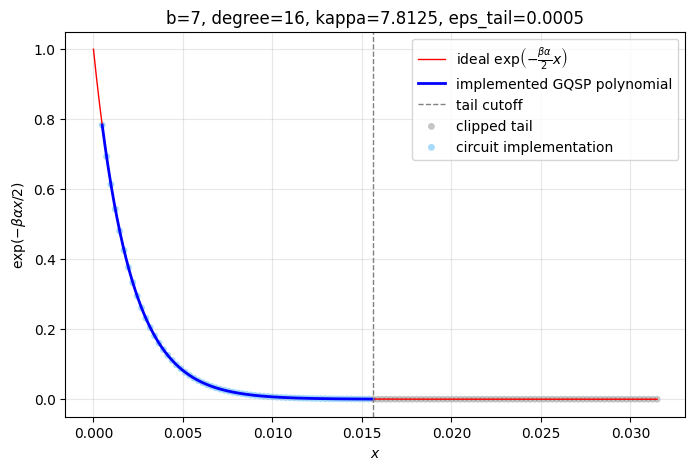

In [3]:
import math 

from monaqa2.qiskit.arithmetic_hybrid import (
    plot_error_hybrid_phase_arithmetic,
    plot_hybrid_phase_arithmetic,
)

w = 7
beta = 10.0
Lambda = 100.0
eps_ops = 1e-3
eps_tail = eps_ops / 2
eps_poly = eps_ops / 2

j_cut = max(
    0,
    min(
        w - 1,
        math.floor(
            math.log2(
                beta * Lambda
                / (2 * math.log(1 / eps_tail))
            )
        ),
    ),
)

d_hyb = math.ceil(
    math.log(1 / eps_tail)
    + math.log(1 / eps_ops)
    + 1
)

gate = plot_hybrid_phase_arithmetic(
    b=w,
    beta=beta,
    alpha=Lambda,
    eps=eps_poly,
    eps_tail=eps_tail,
    degree=d_hyb,
    is_mocked_angles=False,
)


The next plot studies the approximation error as the effective exponential scale varies. The fixed degree is the value $d_{\mathrm{hyb}}$ selected above from Eq. (F14). When tail truncation is active, the effective normalization is

$$
\Lambda_{\mathrm{eff}}
=
\Lambda2^{-j_{\mathrm{cut}}},
$$

so the exponential is approximated only over the retained interval. The discarded tail contributes at most $\varepsilon_{\mathrm{tail}}$.


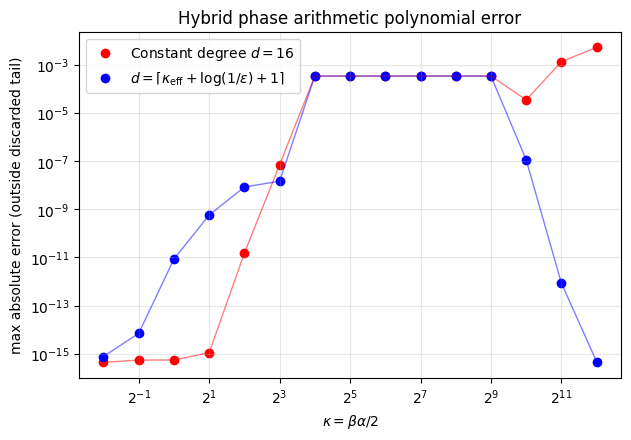

In [4]:
_ = plot_error_hybrid_phase_arithmetic(
    b=w,
    eps=eps_poly,
    eps_tail=eps_tail,
    fixed_degree=d_hyb,
    is_mocked_angles=True,
)
